In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
data_path = Path("../data") / "spy.csv"
if not data_path.exists():
    raise FileNotFoundError(f"{data_path} not found. Expected [data/bnd_df.csv](data/bnd_df.csv)")

spy_df = pd.read_csv(data_path, skiprows=[1, 2], index_col=0, parse_dates=True)

In [3]:
spy_df.head()

,Close,High,Low,Open,Volume
Price,,,,,
2015-01-02,169.687836,170.885565,168.655319,170.472558,121465900
2015-01-05,166.623337,168.812266,166.317716,168.647066,169632600
2015-01-06,165.053909,167.449342,164.260931,166.928950,209151400
2015-01-07,167.110672,167.449340,165.929480,166.375521,125346700
2015-01-08,170.076050,170.290821,168.498375,168.514886,147217800


In [4]:
spy_df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [5]:
spy_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2888 non-null   float64
 1   High    2888 non-null   float64
 2   Low     2888 non-null   float64
 3   Open    2888 non-null   float64
 4   Volume  2888 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 135.4 KB


In [6]:
for col in ["Close", "High", "Low", "Open"]:
    spy_df[col] = pd.to_numeric(spy_df[col], errors="coerce")

spy_df["Volume"] = pd.to_numeric(spy_df["Volume"], errors="coerce").astype("Int64")



In [7]:
spy_df.index = pd.to_datetime(spy_df.index, errors="coerce")
spy_df = spy_df[spy_df.index.notna()].copy()


In [8]:
spy_df.index

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18',
               '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25',
               '2026-06-26', '2026-06-29'],
              dtype='datetime64[us]', name='Price', length=2888, freq=None)

visualization 

closing price over time 

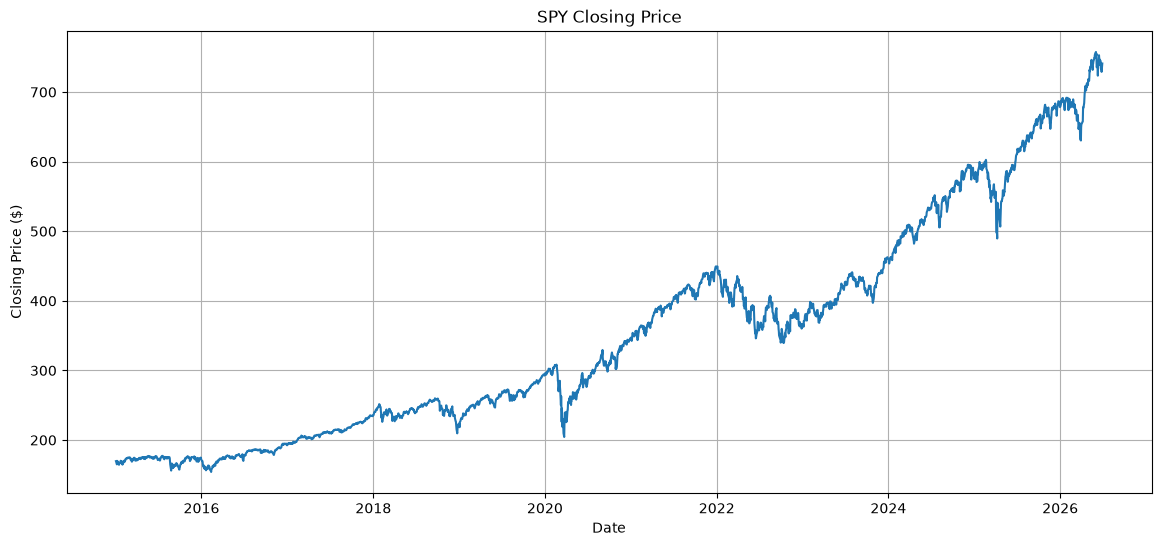

In [9]:
plt.figure(figsize=(14,6))

plt.plot(spy_df.index, spy_df["Close"])

plt.title("SPY Closing Price")

plt.xlabel("Date")

plt.ylabel("Closing Price ($)")

plt.grid(True)

plt.show()

Daily Percentage Returns
how much the investment gained 

In [10]:
spy_df["Daily_Return"] = spy_df["Close"].pct_change()

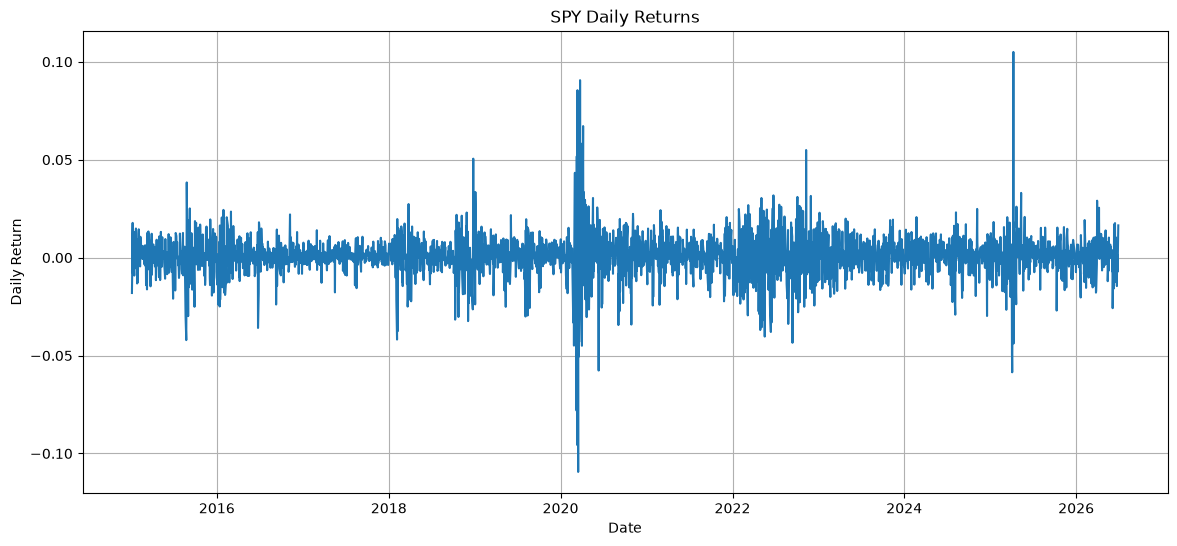

In [11]:
plt.figure(figsize=(14,6))

plt.plot(spy_df.index,
         spy_df["Daily_Return"])

plt.title("SPY Daily Returns")

plt.xlabel("Date")

plt.ylabel("Daily Return")

plt.grid(True)

plt.show()

In [12]:
window = 30

spy_df["Rolling_Mean"] = (
    spy_df["Close"]
    .rolling(window)
    .mean()
)

spy_df["Rolling_STD"] = (
    spy_df["Close"]
    .rolling(window)
    .std()
)

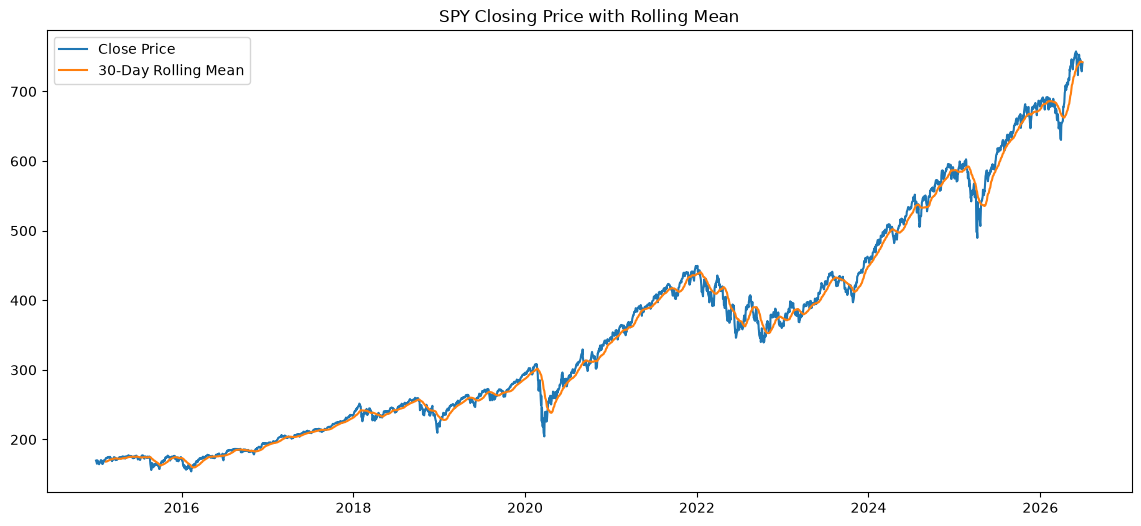

In [13]:
plt.figure(figsize=(14,6))

plt.plot(spy_df["Close"],
         label="Close Price")

plt.plot(spy_df["Rolling_Mean"],
         label="30-Day Rolling Mean")

plt.legend()

plt.title("SPY Closing Price with Rolling Mean")

plt.show()

outlier     

In [14]:
Q1 = spy_df["Daily_Return"].quantile(0.25)
Q3 = spy_df["Daily_Return"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = spy_df[
    (spy_df["Daily_Return"] < lower) |
    (spy_df["Daily_Return"] > upper)
]

In [15]:
outliers.head()

,Close,High,Low,Open,Volume,Daily_Return,Rolling_Mean,Rolling_STD
Price,,,,,,,,
2015-06-29,171.266083,174.942862,171.191050,173.458813,202621300,-0.020970,175.260104,1.386873
2015-08-20,170.057129,173.658862,169.998761,172.174813,194327900,-0.020881,174.808305,1.513881
2015-08-21,164.938019,170.032147,164.679563,168.189585,346588500,-0.030102,174.540122,2.337093
2015-08-24,157.992966,164.646175,152.073435,156.317161,507244300,-0.042107,173.976795,3.817212
2015-08-26,162.128296,162.403418,157.050834,160.144000,339257000,0.038394,172.877373,5.380830


In [16]:
outliers.sort_values("Daily_Return")

,Close,High,Low,Open,Volume,Daily_Return,Rolling_Mean,Rolling_STD
Price,,,,,,,,
2020-03-16,218.627945,234.169340,216.358257,219.840254,297240000,-0.109423,283.679415,25.471631
2020-03-12,226.157074,243.065761,225.765113,233.348961,392220700,-0.095677,287.940467,21.088963
2020-03-09,249.965958,259.044682,249.254974,250.941262,309417300,-0.078095,292.987849,14.971600
2025-04-04,498.269714,518.574044,498.052765,516.404555,217965100,-0.058543,559.032294,17.766416
2020-06-11,275.623108,286.203904,275.073003,285.571255,209243600,-0.057649,273.341594,11.359484
...,...,...,...,...,...,...,...,...
2020-03-26,239.488892,240.955876,228.348799,228.779734,257632800,0.058390,261.915166,33.932692
2020-04-06,242.844620,244.806755,227.541917,236.408138,188061200,0.067166,245.257441,24.719909
2020-03-13,245.490341,247.459226,226.530740,239.811567,329566100,0.085486,286.167255,22.352805


C:\Users\mijuu\AppData\Local\Temp\ipykernel_23736\3825871342.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


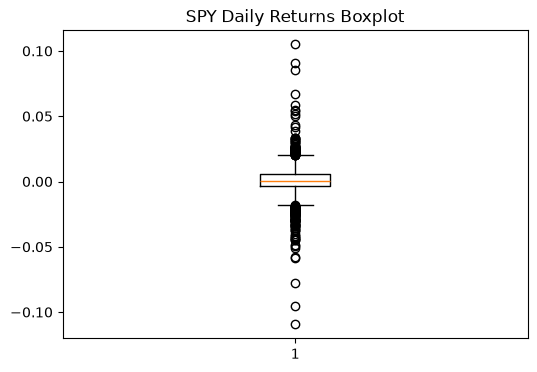

In [17]:
plt.figure(figsize=(6,4))

plt.boxplot(
    spy_df["Daily_Return"].dropna(),
    vert=True
)

plt.title("SPY Daily Returns Boxplot")

plt.show()

In [18]:
from statsmodels.tsa.stattools import adfuller

In [19]:
result = adfuller(
    spy_df["Close"].dropna()
)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 1.308943834402536
p-value: 0.9966585465548378


we fail to reject the null hypothesis. thus it is not stationary ( close price)

In [20]:
result_returns = adfuller(
    spy_df["Daily_Return"].dropna()
)

print("ADF Statistic:", result_returns[0])
print("p-value:", result_returns[1])

ADF Statistic: -17.572187714625983
p-value: 4.046278950126476e-30


ADF test provides strong evidence that the daily return series is stationary, thus the null hypothesis of non-stationarity is rejected

## Risk metrics

### VaR

In [21]:
returns = spy_df["Daily_Return"].dropna()

In [22]:
VaR_95 = returns.quantile(0.05)

print(VaR_95)

-0.01664992956003688


The historical 95% Value at Risk (VaR) for SPY is approximately -1.6%, meaning that on 95% of trading days the daily loss is expected to be less than 1.6%, while only about 5% of trading days experience larger losses.

### Sharpe Ratio

"How much return am I getting for every unit of risk I take?"

In [23]:
mean_return = returns.mean()

In [24]:
std_return = returns.std()

In [25]:
annual_return = mean_return * 252

In [26]:
annual_volatility = std_return * np.sqrt(252)

In [27]:
risk_free_rate = 0

In [28]:
sharpe_ratio = (
    annual_return - risk_free_rate
) / annual_volatility

print(sharpe_ratio)

0.8174624090848251


For each unit of risk, the investment generated 0.8 units of return.

# model training  

In [29]:
spy = spy_df[["Close"]].copy()

In [30]:
train = spy.loc[:'2024-12-31']

test = spy.loc['2025-01-01':]

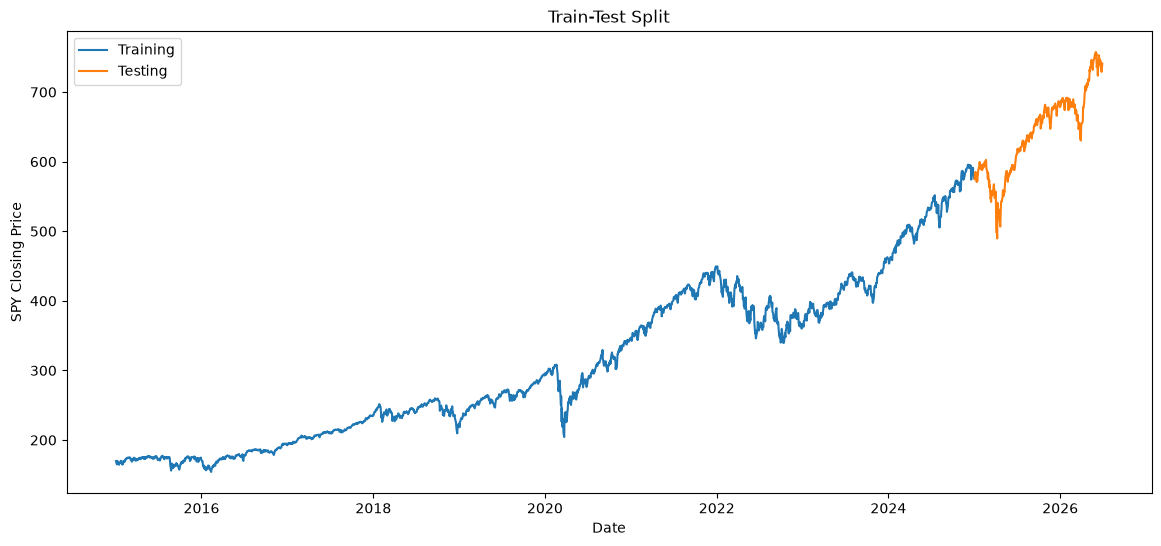

In [31]:
plt.figure(figsize=(14,6))

plt.plot(train.index,
         train["Close"],
         label="Training")

plt.plot(test.index,
         test["Close"],
         label="Testing")

plt.title("Train-Test Split")

plt.xlabel("Date")

plt.ylabel("SPY Closing Price")

plt.legend()

plt.show()

In [32]:
from pmdarima import auto_arima

In [33]:
model = auto_arima(
    train["Close"],
    seasonal=False,
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=13362.846, Time=2.55 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=13367.335, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=13360.523, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=13360.957, Time=0.19 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=13370.856, Time=0.05 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=13360.923, Time=0.27 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=13361.144, Time=0.54 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=13362.798, Time=0.95 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=13364.733, Time=0.06 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 4.846 seconds


In [34]:

forecast = model.predict(
    n_periods=len(test)
)

c:\Users\mijuu\Documents\mijuuhailu\time-series-forecast\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\mijuu\Documents\mijuuhailu\time-series-forecast\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


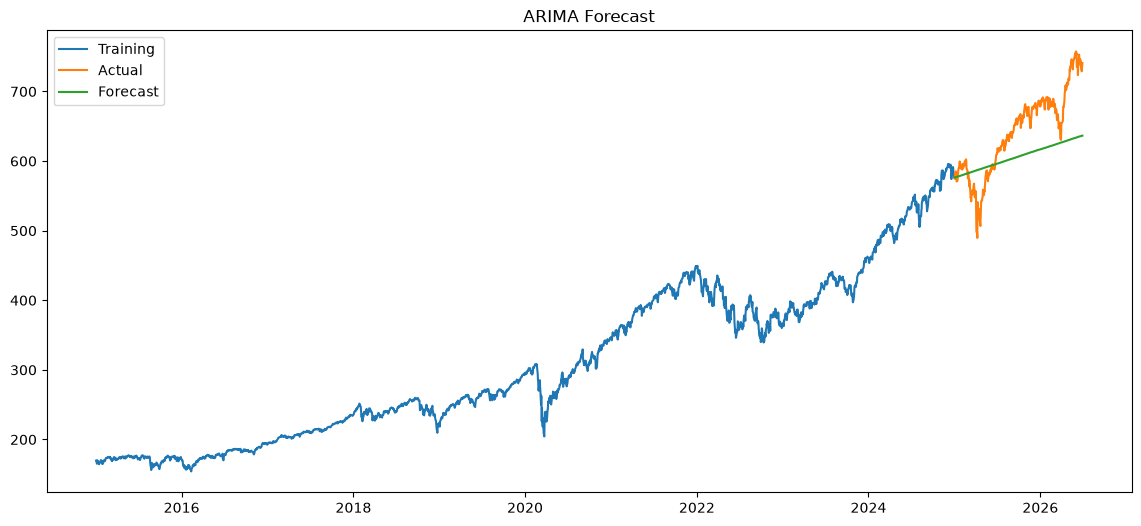

In [35]:
plt.figure(figsize=(14,6))

plt.plot(train.index,
         train["Close"],
         label="Training")

plt.plot(test.index,
         test["Close"],
         label="Actual")

plt.plot(test.index,
         forecast,
         label="Forecast")

plt.legend()

plt.title("ARIMA Forecast")

plt.show()

## evaluation metrics 

### ARIMA

In [36]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [37]:
mae = mean_absolute_error(
    test["Close"],
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test["Close"],
        forecast
    )
)

mape = mean_absolute_percentage_error(
    test["Close"],
    forecast
)

In [38]:
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.4f}")

MAE : 47.15
RMSE: 56.04
MAPE: 0.0712


### LSTM

Training Shape: (2456, 60, 1)


c:\Users\mijuu\Documents\mijuuhailu\time-series-forecast\myenv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0135
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0024
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0019
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0017
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0015
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0014
Epoch 7/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0013
Epoch 8/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0012
Epoch 9/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0013
Epoch 10/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0012
Epoch 11/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0011
Epoch 12/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.7266e-04
Epoch 13/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0011
Epoch 14/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.7637e-04
Epoch 15/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0

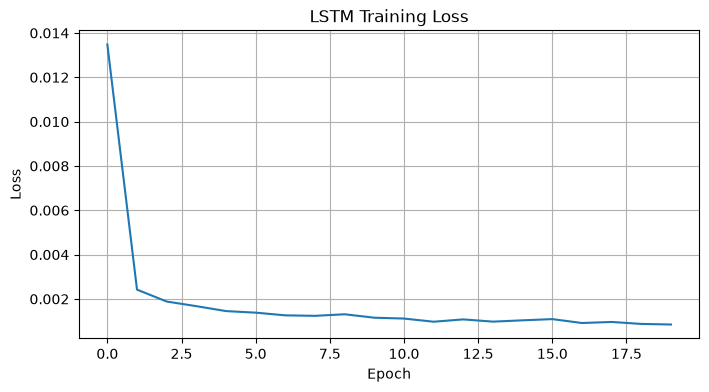

In [39]:
# =====================================================
# LSTM MODEL FOR TESLA STOCK PRICE FORECASTING
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# =====================================================
# 1. Select Closing Prices
# =====================================================

spy = spy_df[['Close']].copy()

# =====================================================
# 2. Train-Test Split (Chronological)
# =====================================================

train = spy.loc[:'2024-12-31']
test = spy.loc['2025-01-01':]

# =====================================================
# 3. Scale the Data
# =====================================================

scaler = MinMaxScaler(feature_range=(0,1))

scaled_train = scaler.fit_transform(train)
scaled_test = scaler.transform(test)

# =====================================================
# 4. Create Training Sequences
# =====================================================

window = 60

X_train = []
y_train = []

for i in range(window, len(scaled_train)):
    X_train.append(scaled_train[i-window:i, 0])
    y_train.append(scaled_train[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

# =====================================================
# 5. Reshape for LSTM
# Shape = (samples, time_steps, features)
# =====================================================

X_train = X_train.reshape((X_train.shape[0],
                           X_train.shape[1],
                           1))

print("Training Shape:", X_train.shape)

# =====================================================
# 6. Build the LSTM Model
# =====================================================

model = Sequential()


model.add(
    LSTM(
        units=50,
        input_shape=(window,1)
    )
)
model.add(Dropout(0.2))

model.add(Dense(1))

# =====================================================
# 7. Compile
# =====================================================

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# =====================================================
# 8. Train
# =====================================================

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=1
)

# =====================================================
# 9. Plot Training Loss
# =====================================================

plt.figure(figsize=(8,4))

plt.plot(history.history['loss'])

plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

Test Shape: (372, 60, 1)


c:\Users\mijuu\Documents\mijuuhailu\time-series-forecast\myenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


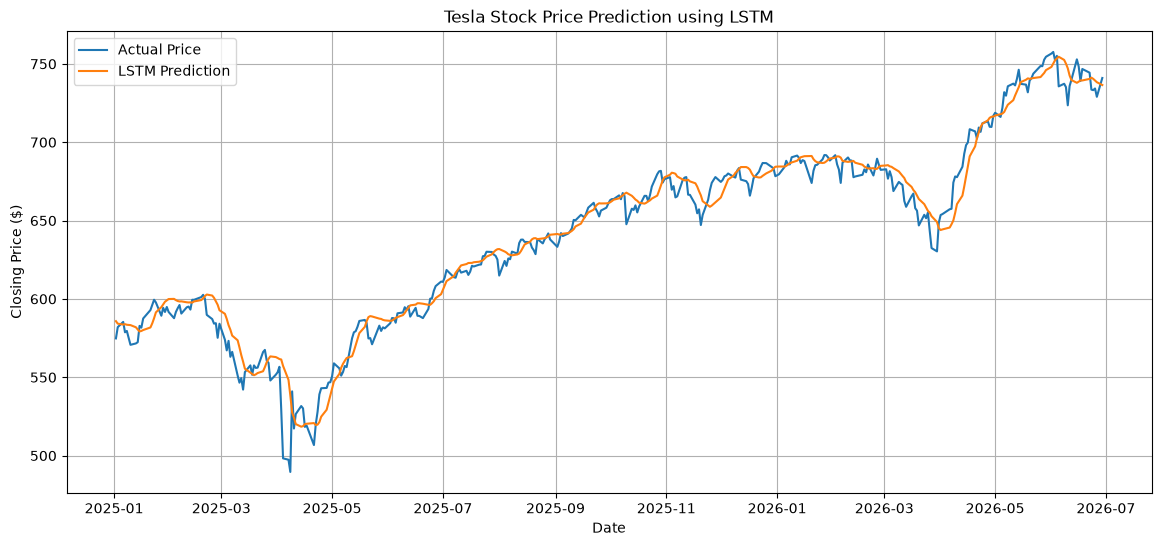

LSTM MAE : 7.09
LSTM RMSE: 9.93
LSTM MAPE: 1.14%

Model Comparison
   Model        MAE      RMSE   MAPE (%)
0  ARIMA  54.440000  70.54000  17.240000
1   LSTM   7.088806   9.93499   1.144122


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# ============================================
# Prepare Test Data
# ============================================

dataset_total = pd.concat(
    (train["Close"], test["Close"]),
    axis=0
)

inputs = dataset_total[
    len(dataset_total) - len(test) - window:
].values

inputs = inputs.reshape(-1,1)

inputs = scaler.transform(inputs)

# ============================================
# Create Test Sequences
# ============================================

X_test = []

for i in range(window, len(inputs)):
    X_test.append(inputs[i-window:i,0])

X_test = np.array(X_test)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("Test Shape:", X_test.shape)

# ============================================
# Predict
# ============================================

predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

# ============================================
# Plot
# ============================================

plt.figure(figsize=(14,6))

plt.plot(
    test.index,
    test["Close"],
    label="Actual Price"
)

plt.plot(
    test.index,
    predictions,
    label="LSTM Prediction"
)

plt.title("Tesla Stock Price Prediction using LSTM")

plt.xlabel("Date")

plt.ylabel("Closing Price ($)")

plt.legend()

plt.grid(True)

plt.show()

# ============================================
# Evaluation
# ============================================

mae = mean_absolute_error(
    test["Close"],
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        test["Close"],
        predictions
    )
)

mape = mean_absolute_percentage_error(
    test["Close"],
    predictions
)

print(f"LSTM MAE : {mae:.2f}")
print(f"LSTM RMSE: {rmse:.2f}")
print(f"LSTM MAPE: {mape*100:.2f}%")

# ============================================
# Compare with ARIMA
# ============================================

comparison = pd.DataFrame({
    "Model": ["ARIMA", "LSTM"],
    "MAE": [54.44, mae],
    "RMSE": [70.54, rmse],
    "MAPE (%)": [17.24, mape*100]
})

print("\nModel Comparison")
print(comparison)

# prediction

In [41]:
future_days = 252

last_sequence = scaled_train[-window:]

future_predictions = []

current_sequence = last_sequence.copy()

for _ in range(future_days):

    prediction = model.predict(
        current_sequence.reshape(1, window, 1),
        verbose=0
    )

    future_predictions.append(prediction[0,0])

    current_sequence = np.append(
        current_sequence[1:],
        prediction
    )

In [42]:
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)
# convert back to dollar 

confidence = 1.96 * rmse * np.sqrt(np.arange(1, future_days + 1) / future_days)

lower = future_predictions.flatten() - confidence
upper = future_predictions.flatten() + confidence


In [43]:
future_dates = pd.bdate_range(
    start=test.index[-1] + pd.Timedelta(days=1),
    periods=future_days
)

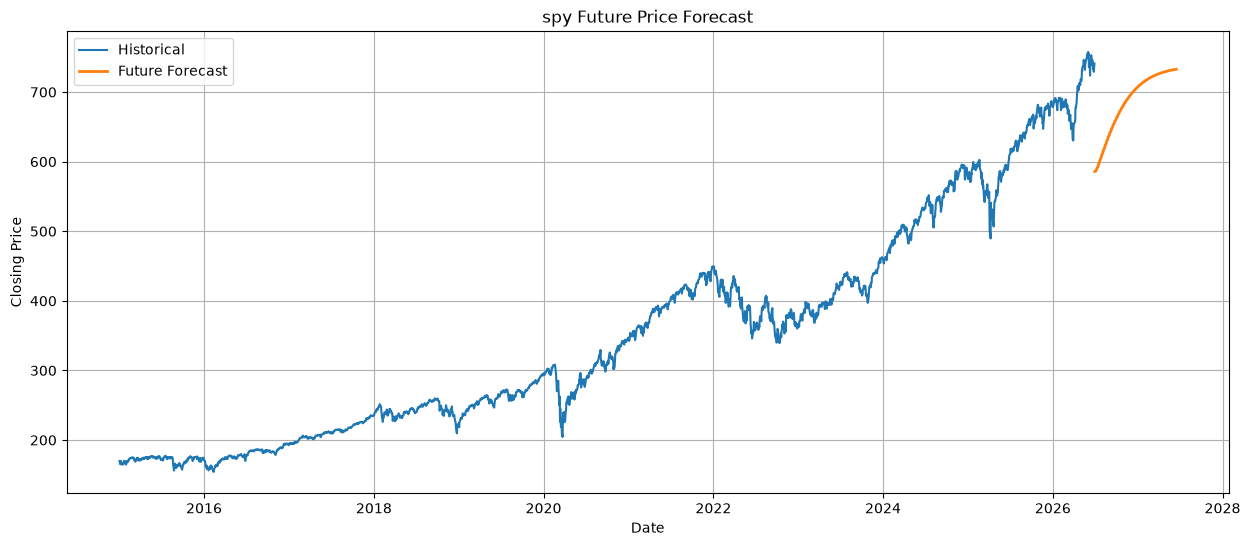

In [46]:
plt.figure(figsize=(15,6))

plt.plot(
    spy.index,
    spy["Close"],
    label="Historical"
)

plt.plot(
    future_dates,
    future_predictions,
    label="Future Forecast",
    linewidth=2
)

plt.title("spy Future Price Forecast")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.legend()

plt.grid(True)

plt.show()